# Data Cleaning

In [1]:
%reset -f

Imports

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import gc
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

Loading the datasheets

In [3]:
DATA_RAW = Path("../data/raw")

studentInfo = pd.read_csv(DATA_RAW / "studentInfo.csv")
studentVle = pd.read_csv(DATA_RAW / "studentVle.csv")
assessments = pd.read_csv(DATA_RAW / "assessments.csv")
studentAssessment = pd.read_csv(DATA_RAW / "studentAssessment.csv")
courses = pd.read_csv(DATA_RAW / "courses.csv")
vle = pd.read_csv(DATA_RAW / "vle.csv")
studentReg = pd.read_csv(DATA_RAW / "studentRegistration.csv")

### Tables Overview

In [4]:
datasets = {
    "studentInfo": studentInfo,
    "studentVle": studentVle,
    "assessments": assessments,
    "studentAssessment": studentAssessment,
    "courses": courses,
    "vle": vle,
    "studentRegistration": studentReg
}

for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print("Shape:", df.shape)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())


studentInfo
Shape: (32593, 12)

Missing values:
 code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64

Duplicate rows: 0

studentVle
Shape: (10655280, 6)

Missing values:
 code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

Duplicate rows: 787170

assessments
Shape: (206, 6)

Missing values:
 code_module          0
code_presentation    0
id_assessment        0
assessment_type      0
date                 0
weight               0
dtype: int64

Duplicate rows: 0

studentAssessment
Shape: (173912, 5)

Missing values:
 id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: 

In [5]:
# =============================================================================
# SECTION 2 — Constants
# =============================================================================

KEYS        = ["id_student", "code_module", "code_presentation"]
COURSE_KEYS = ["code_module", "code_presentation"]
eps         = 1e-9

CONTENT_TYPES    = {"subpage","homepage","oucontent","resource","url","page",
                    "folder","glossary","htmlactivity","dualpane","repeatactivity"}
ASSESSMENT_TYPES = {"quiz","externalquiz","questionnaire"}
SOCIAL_TYPES     = {"forumng","ouwiki","oucollaborate","ouelluminate",
                    "dataplus","sharedsubpage"}
dim_keep         = {"content", "assessment", "social"}

In [6]:
# =============================================================================
# SECTION 3 — Clean studentReg
# =============================================================================

studentReg["date_unregistration"] = pd.to_numeric(
    studentReg["date_unregistration"], errors="coerce")
studentReg["date_registration"] = pd.to_numeric(
    studentReg["date_registration"], errors="coerce")

studentReg = studentReg[
    ~(studentReg["date_unregistration"].notna() &
      (studentReg["date_unregistration"] < 0))
].copy()

studentReg["registration_missing_flag"] = studentReg["date_registration"].isna().astype(int)
studentReg["unregistered_flag"]         = studentReg["date_unregistration"].notna().astype(int)
studentReg["unregistration_week"]       = (
    (studentReg["date_unregistration"] // 7) + 1
).fillna(-1).astype(int)
studentReg["date_registration"]         = studentReg["date_registration"].fillna(0)
studentReg["late_registration_flag"]    = (studentReg["date_registration"] > 0).astype(int)



In [7]:
# =============================================================================
# SECTION 4 — Courses + course_windows with FIXED quarter cutoffs
# =============================================================================

courses = courses.copy()
courses["module_presentation_length"] = pd.to_numeric(
    courses["module_presentation_length"], errors="coerce")
courses["course_weeks"] = np.ceil(
    courses["module_presentation_length"] / 7).astype("Int64")

non_stem_modules    = {"AAA", "BBB", "GGG"}
courses["course_type_stem"] = (
    ~courses["code_module"].astype(str).str.upper().str.strip().isin(non_stem_modules)
).astype(int)

print("Unique course week lengths:")
print(courses["course_weeks"].value_counts(dropna=False))

def assign_quarter_cutoffs(course_weeks):
    """
    Paper's fixed cutoffs:
      38-week: Q1=10, Q2=19, Q3=29, Q4=38
      34-week: Q1=9,  Q2=17, Q3=26, Q4=34
    All other lengths: proportional fallback.
    """
    if course_weeks == 38:
        return 10, 19, 29, 38
    elif course_weeks == 34:
        return 9, 17, 26, 34
    else:
        q1 = max(1, int(np.ceil(course_weeks * 0.25)))
        q2 = min(int(np.ceil(course_weeks * 0.50)), course_weeks)
        q3 = min(int(np.ceil(course_weeks * 0.75)), course_weeks)
        q4 = course_weeks
        return q1, q2, q3, q4

course_windows = courses[COURSE_KEYS + ["course_weeks"]].drop_duplicates().copy()
course_windows["course_weeks"] = course_windows["course_weeks"].fillna(1).clip(lower=1).astype(int)
cutoffs = course_windows["course_weeks"].apply(
    lambda cw: pd.Series(
        assign_quarter_cutoffs(cw), index=["q1_end","q2_end","q3_end","q4_end"]))
course_windows = pd.concat([course_windows, cutoffs], axis=1)
course_windows["q1_start"] = 1
course_windows["q2_start"] = course_windows["q1_end"] + 1
course_windows["q3_start"] = course_windows["q2_end"] + 1
course_windows["q4_start"] = course_windows["q3_end"] + 1

print("\nCourse windows:")
print(course_windows[COURSE_KEYS + ["course_weeks","q1_end","q2_end","q3_end","q4_end"]])



Unique course week lengths:
course_weeks
39    9
35    8
38    4
34    1
Name: count, dtype: Int64

Course windows:
   code_module code_presentation  course_weeks  q1_end  q2_end  q3_end  q4_end
0          AAA             2013J            39      10      20      30      39
1          AAA             2014J            39      10      20      30      39
2          BBB             2013J            39      10      20      30      39
3          BBB             2014J            38      10      19      29      38
4          BBB             2013B            35       9      18      27      35
5          BBB             2014B            34       9      17      26      34
6          CCC             2014J            39      10      20      30      39
7          CCC             2014B            35       9      18      27      35
8          DDD             2013J            38      10      19      29      38
9          DDD             2014J            38      10      19      29      38
10         DDD 

In [8]:
# =============================================================================
# SECTION 5 — Encode studentInfo
# =============================================================================

studentInfo = studentInfo.copy()
studentInfo["target_at_risk"] = (
    studentInfo["final_result"].isin(["Fail","Withdrawn"])).astype(int)
studentInfo["gender_bin"]     = (
    studentInfo["gender"].astype(str).str.upper() == "M").astype(int)
studentInfo["disability_bin"] = (
    studentInfo["disability"].astype(str).str.upper() == "Y").astype(int)

age_map = {"0-35": 0, "35-55": 1, "55<=": 2, "55+": 2}
studentInfo["age_band_ord"] = studentInfo["age_band"].map(age_map)
studentInfo["age_band_missing_flag"] = (
    studentInfo["age_band"].isna() |
    ~studentInfo["age_band"].isin(age_map.keys())).astype(int)
studentInfo["age_band_ord"] = studentInfo["age_band_ord"].fillna(
    studentInfo["age_band_ord"].median())

edu_map = {
    "No Formal quals": 0, "Lower Than A Level": 1,
    "A Level or Equivalent": 2, "HE Qualification": 3,
    "Post Graduate Qualification": 4}
studentInfo["highest_education_ord"] = studentInfo["highest_education"].map(edu_map)
studentInfo["highest_education_missing_flag"] = (
    studentInfo["highest_education"].isna() |
    ~studentInfo["highest_education"].isin(edu_map.keys())).astype(int)
studentInfo["highest_education_ord"] = studentInfo["highest_education_ord"].fillna(
    studentInfo["highest_education_ord"].median())

def map_region_to_nation(region):
    if pd.isna(region): return "Other"
    r = str(region).lower()
    if "scotland" in r:                 return "Scotland"
    if "wales" in r:                    return "Wales"
    if "ireland" in r:                  return "Northern_Ireland"
    if "england" in r or "region" in r: return "England"
    return "Other"

studentInfo["nation"] = studentInfo["region"].apply(map_region_to_nation)
nation_ohe  = pd.get_dummies(studentInfo["nation"], prefix="nation", dummy_na=False)
studentInfo = pd.concat([studentInfo, nation_ohe], axis=1)

def bin_imd_5(x):
    x = str(x).strip()
    if x in {"0-10%","10-20%"}:   return "VeryLow"
    if x in {"20-30%","30-40%"}:  return "Low"
    if x in {"40-50%","50-60%"}:  return "Medium"
    if x in {"60-70%","70-80%"}:  return "High"
    if x in {"80-90%","90-100%"}: return "VeryHigh"
    return "Unknown"

studentInfo["imd_band"]     = studentInfo["imd_band"].fillna("Unknown").astype(str)
studentInfo["imd_5cat"]     = studentInfo["imd_band"].apply(bin_imd_5)
imd_ord_map = {"VeryLow":0,"Low":1,"Medium":2,"High":3,"VeryHigh":4,"Unknown":np.nan}
studentInfo["imd_ordinal"]  = studentInfo["imd_5cat"].map(imd_ord_map)
studentInfo["imd_unknown_flag"] = studentInfo["imd_ordinal"].isna().astype(int)
studentInfo["imd_ordinal"]  = studentInfo["imd_ordinal"].fillna(
    studentInfo["imd_ordinal"].median()).astype(float)

studentInfo.drop(
    columns=["gender","disability","age_band","highest_education",
             "region","nation","imd_band","imd_5cat"], inplace=True)


In [9]:
# =============================================================================
# SECTION 6 — Build base_static
# =============================================================================

courses_no_weeks = courses.drop(columns=["course_weeks"], errors="ignore")
base_static = (
    studentInfo
    .merge(studentReg, on=KEYS, how="inner")
    .merge(courses_no_weeks, on=COURSE_KEYS, how="inner")
    .merge(course_windows[COURSE_KEYS + ["course_weeks","q1_end","q2_end","q3_end","q4_end"]],
           on=COURSE_KEYS, how="inner")
)
print(f"\nbase_static: {base_static.shape}  |  at-risk: {base_static['target_at_risk'].mean()*100:.1f}%")




base_static: (29915, 32)  |  at-risk: 48.6%


In [10]:
# =============================================================================
# SECTION 7 — Cross-presentation split
# Latest presentation per module (chronological) = test
# All earlier presentations = train
# =============================================================================

def parse_presentation_order(pres):
    """Parse '2013B', '2013J', '2014B' → (year, season) for chronological ordering."""
    pres = str(pres).strip()
    try:
        year         = int(pres[:4])
        season_order = {"B": 0, "J": 1}.get(pres[4:].upper(), 0)
        return (year, season_order)
    except:
        return (0, 0)

pres_per_module = (
    base_static.groupby(COURSE_KEYS).size().reset_index(name="n_students"))
pres_per_module["pres_order"] = pres_per_module["code_presentation"].apply(
    parse_presentation_order)
pres_per_module = pres_per_module.sort_values(
    ["code_module","pres_order"]).reset_index(drop=True)

print("\nAll presentations (chronological):")
print(pres_per_module[["code_module","code_presentation","n_students"]].to_string(index=False))

single_pres = (pres_per_module.groupby("code_module")["code_presentation"]
               .nunique().pipe(lambda s: s[s == 1]).index.tolist())
if single_pres:
    print(f"\n⚠️  Modules with 1 presentation (train only): {single_pres}")

# Latest presentation per module = test
test_presentations = (
    pres_per_module.sort_values(["code_module","pres_order"])
    .groupby("code_module").last().reset_index()
    [["code_module","code_presentation"]]
)
print("\nHeld-out test presentations:")
print(test_presentations.to_string(index=False))

test_set  = set(zip(test_presentations["code_module"], test_presentations["code_presentation"]))
test_mask = base_static.apply(
    lambda r: (r["code_module"], r["code_presentation"]) in test_set, axis=1)

train_keys = base_static.loc[~test_mask, KEYS].copy()
test_keys  = base_static.loc[test_mask,  KEYS].copy()

print(f"\nTrain: {len(train_keys):,} students | "
      f"{base_static.loc[~test_mask,'code_presentation'].nunique()} presentations")
print(f"Test:  {len(test_keys):,} students | "
      f"{base_static.loc[test_mask,'code_presentation'].nunique()} presentations")

assert len(
    set(zip(train_keys["code_module"], train_keys["code_presentation"])) &
    set(zip(test_keys["code_module"],  test_keys["code_presentation"]))
) == 0, "Presentation leakage detected!"
print("✓ No presentation overlap")




All presentations (chronological):
code_module code_presentation  n_students
        AAA             2013J         376
        AAA             2014J         352
        BBB             2013B        1645
        BBB             2013J        2003
        BBB             2014B        1351
        BBB             2014J        2053
        CCC             2014B        1686
        CCC             2014J        2285
        DDD             2013B        1226
        DDD             2013J        1748
        DDD             2014B        1127
        DDD             2014J        1655
        EEE             2013J         986
        EEE             2014B         644
        EEE             2014J        1121
        FFF             2013B        1529
        FFF             2013J        2112
        FFF             2014B        1377
        FFF             2014J        2170
        GGG             2013J         930
        GGG             2014B         810
        GGG             2014J         72

In [11]:
# =============================================================================
# SECTION 8 — Process VLE to weekly level (once, shared by both cohorts)
# =============================================================================

studentVle["date"]      = pd.to_numeric(studentVle["date"],      errors="coerce")
studentVle["sum_click"] = pd.to_numeric(
    studentVle["sum_click"], errors="coerce").fillna(0).clip(lower=0)

studentVle_daily = (
    studentVle
    .groupby(["id_student","code_module","code_presentation","id_site","date"], as_index=False)
    .agg(sum_click=("sum_click","sum"))
)
vle_lookup           = vle[["id_site","activity_type"]].drop_duplicates()
studentVle_daily_enr = studentVle_daily.merge(vle_lookup, on="id_site", how="left")
del studentVle_daily, vle_lookup, studentVle
gc.collect()

studentVle_daily_enr = studentVle_daily_enr[studentVle_daily_enr["date"] >= 0].copy()
studentVle_daily_enr["week"] = (studentVle_daily_enr["date"] // 7) + 1

def map_engagement_dim(activity_type):
    if pd.isna(activity_type): return "unknown"
    a = str(activity_type).strip().lower()
    if a in CONTENT_TYPES:    return "content"
    if a in ASSESSMENT_TYPES: return "assessment"
    if a in SOCIAL_TYPES:     return "social"
    return "other"

studentVle_daily_enr["engagement_dim"] = studentVle_daily_enr["activity_type"].apply(
    map_engagement_dim)
studentVle_daily_enr = studentVle_daily_enr[
    ["id_student","code_module","code_presentation","week","sum_click","engagement_dim"]].copy()

studentVle_weekly = (
    studentVle_daily_enr
    .groupby(["id_student","code_module","code_presentation","week","engagement_dim"],
             as_index=False)
    .agg(sum_click=("sum_click","sum"))
)
print(f"studentVle_weekly shape: {studentVle_weekly.shape}")
del studentVle_daily_enr
gc.collect()

# # Outlier capping (applied once — threshold is not a normaliser)
# CAP_Q      = 0.99
# group_cols = ["code_module","code_presentation","week","engagement_dim"]
# cap_tbl = (
#     studentVle_weekly
#     .groupby(group_cols, as_index=False)["sum_click"]
#     .quantile(CAP_Q).rename(columns={"sum_click":"cap_hi"})
# )
# studentVle_weekly = studentVle_weekly.merge(cap_tbl, on=group_cols, how="left")
# studentVle_weekly["sum_click"] = np.minimum(
#     studentVle_weekly["sum_click"],
#     studentVle_weekly["cap_hi"].fillna(studentVle_weekly["sum_click"]))
# studentVle_weekly.drop(columns=["cap_hi"], inplace=True)
# del cap_tbl
# gc.collect()

# Clean assessments (once, shared)
assess_clean = assessments.copy()
assess_clean["assessment_type"] = assess_clean["assessment_type"].astype(str).str.lower()
assess_clean = assess_clean[assess_clean["assessment_type"] != "exam"].copy()
assess_clean["date"] = pd.to_numeric(assess_clean["date"], errors="coerce")
assess_clean = assess_clean.dropna(subset=["date"])
assess_clean = assess_clean[
    ["id_assessment","code_module","code_presentation","date"]
].rename(columns={"date":"due_date"})

sa = studentAssessment.copy()
sa = sa[sa["date_submitted"].notna()].copy()
sa["date_submitted"] = pd.to_numeric(sa["date_submitted"], errors="coerce").clip(lower=0)
sa = sa[["id_assessment","id_student","date_submitted"]]

sub_all = sa.merge(assess_clean, on="id_assessment", how="inner", validate="m:1")
sub_all = sub_all.merge(
    course_windows[COURSE_KEYS + ["q1_end","q2_end","q3_end","q4_end"]],
    on=COURSE_KEYS, how="inner", validate="m:1")

print("Raw data processing complete ✓")

studentVle_weekly shape: (1085419, 6)
Raw data processing complete ✓


In [12]:
# =============================================================================
# SECTION 9 — Feature engineering functions
# Every function takes cohort_keys — all reference stats within cohort only
# =============================================================================
def cap_outliers_within_cohort(vle_weekly, cohort_keys, cap_q=0.99):
    # keep only this cohort first
    vle_c = vle_weekly.merge(cohort_keys, on=KEYS, how="inner")

    group_cols = ["code_module","code_presentation","week","engagement_dim"]

    cap_tbl = (
        vle_c.groupby(group_cols, as_index=False)["sum_click"]
        .quantile(cap_q)
        .rename(columns={"sum_click":"cap_hi"})
    )

    vle_c = vle_c.merge(cap_tbl, on=group_cols, how="left")
    vle_c["sum_click"] = np.minimum(vle_c["sum_click"], vle_c["cap_hi"].fillna(vle_c["sum_click"]))
    vle_c = vle_c.drop(columns=["cap_hi"])

    return vle_c
    
def build_weekly_norm_features(studentVle_weekly, cohort_keys, course_windows):
    """Weekly norm columns. Denominators from cohort only."""
    vle_w = studentVle_weekly[studentVle_weekly["engagement_dim"].isin(dim_keep)].copy()
    vle_w = vle_w.merge(course_windows[COURSE_KEYS+["course_weeks"]],
                        on=COURSE_KEYS, how="inner", validate="m:1")
    vle_w = vle_w[(vle_w["week"] >= 1) & (vle_w["week"] <= vle_w["course_weeks"])].copy()
    vle_w["week"] = pd.to_numeric(vle_w["week"], errors="coerce")
    vle_w = vle_w.dropna(subset=["week"]).copy()
    vle_w["week"] = vle_w["week"].astype(int)

    vle_cohort = vle_w.merge(cohort_keys, on=KEYS, how="inner")
    course_week_dim = (
        vle_cohort
        .groupby(COURSE_KEYS+["week","engagement_dim"], as_index=False)
        .agg(course_clicks=("sum_click","sum"))
    )
    vle_cohort = vle_cohort.merge(
        course_week_dim, on=COURSE_KEYS+["week","engagement_dim"],
        how="left", validate="m:1")
    vle_cohort["share_clicks"] = np.where(
        vle_cohort["course_clicks"] > 0,
        vle_cohort["sum_click"] / (vle_cohort["course_clicks"] + eps), 0.0)

    weekly_wide = (
        vle_cohort.pivot_table(
            index=KEYS, columns=["week","engagement_dim"],
            values="share_clicks", fill_value=0.0)
        .reset_index()
    )
    weekly_wide.columns = [
        c[0] if (isinstance(c,tuple) and (c[1]=="" or c[1] is None)) else c
        for c in weekly_wide.columns
    ]
    def _col_name(col):
        if isinstance(col, tuple):
            wk, dim = col
            return f"wk{int(wk):02d}_{dim}_norm"
        return col
    return weekly_wide.rename(columns=_col_name)


In [13]:
def add_weekly_aggregates(df, course_weeks_col="course_weeks", suffix="_norm", eps=1e-9):
    """Course-length-aware aggregated features from weekly norm columns."""
    pat   = re.compile(rf"^wk(\d{{2}})_(content|assessment|social){re.escape(suffix)}$")
    weeks = sorted({int(pat.match(c).group(1)) for c in df.columns if pat.match(c)})
    if not weeks:
        return df.copy()
    max_w = max(weeks)

    Xc = df.reindex(columns=[f"wk{w:02d}_content{suffix}"    for w in weeks], fill_value=0.0).to_numpy(float)
    Xa = df.reindex(columns=[f"wk{w:02d}_assessment{suffix}"  for w in weeks], fill_value=0.0).to_numpy(float)
    Xs = df.reindex(columns=[f"wk{w:02d}_social{suffix}"      for w in weeks], fill_value=0.0).to_numpy(float)
    Xt = Xc + Xa + Xs

    cw         = pd.to_numeric(df[course_weeks_col], errors="coerce").fillna(max_w).clip(1,max_w).to_numpy(int)
    week_index = np.array(weeks, dtype=int)[None,:]
    valid_mask = (week_index <= cw[:,None]).astype(float)
    Xc_v, Xa_v, Xs_v, Xt_v = Xc*valid_mask, Xa*valid_mask, Xs*valid_mask, Xt*valid_mask

    content_eng      = Xc_v.sum(axis=1)
    assess_eng       = Xa_v.sum(axis=1)
    social_eng       = Xs_v.sum(axis=1)
    total_eng        = Xt_v.sum(axis=1)
    content_ratio    = content_eng    / (total_eng + eps)
    assessment_ratio = assess_eng     / (total_eng + eps)
    social_ratio     = social_eng     / (total_eng + eps)
    active_weeks     = (Xt_v > 0).sum(axis=1).astype(int)
    weeks_observed   = cw
    active_weeks_ratio = active_weeks / (weeks_observed + eps)

    row_sum  = Xt_v.sum(axis=1, keepdims=True)
    P        = np.divide(Xt_v, row_sum + eps)
    logP     = np.zeros_like(P)
    m        = P > 0
    logP[m]  = np.log(P[m])
    ent      = -(P * logP).sum(axis=1)
    ent_norm = ent / (np.log(weeks_observed) + eps)

    new_feat = pd.DataFrame({
        f"content_engagement{suffix}":           content_eng,
        f"assessment_engagement{suffix}":        assess_eng,
        f"social_engagement{suffix}":            social_eng,
        f"total_engagement{suffix}":             total_eng,
        f"content_ratio{suffix}":                content_ratio,
        f"assessment_ratio{suffix}":             assessment_ratio,
        f"social_ratio{suffix}":                 social_ratio,
        f"active_weeks{suffix}":                 active_weeks,
        f"weeks_observed{suffix}":               weeks_observed,
        f"active_weeks_ratio{suffix}":           active_weeks_ratio,
        f"engagement_entropy{suffix}":           ent,
        f"engagement_week_entropy_norm{suffix}": ent_norm,
    }, index=df.index)
    return pd.concat([df.copy(), new_feat], axis=1).copy()


In [14]:
def build_quarter_norm_features(studentVle_weekly, cohort_keys,
                                 course_windows, q_end_col, q_label):
    """Quarter engagement norm features. Denominators from cohort only."""
    vle_q = studentVle_weekly.merge(
        course_windows[COURSE_KEYS+["course_weeks","q1_end","q2_end","q3_end","q4_end"]],
        on=COURSE_KEYS, how="inner", validate="m:1").copy()
    vle_q = vle_q[(vle_q["week"] >= 1) & (vle_q["week"] <= vle_q["course_weeks"])].copy()

    df        = vle_q[vle_q["week"] <= vle_q[q_end_col]].copy()
    df_cohort = df.merge(cohort_keys, on=KEYS, how="inner")

    course_dim = (
        df_cohort[df_cohort["engagement_dim"].isin(dim_keep)]
        .groupby(COURSE_KEYS+["engagement_dim"], as_index=False)
        .agg(course_clicks=("sum_click","sum"))
    )
    course_total = (
        df_cohort.groupby(COURSE_KEYS, as_index=False)
        .agg(course_total_clicks=("sum_click","sum"))
    )
    student_dim = (
        df[df["engagement_dim"].isin(dim_keep)]
        .merge(cohort_keys, on=KEYS, how="inner")
        .groupby(KEYS+["engagement_dim"], as_index=False)
        .agg(clicks=("sum_click","sum"))
    )
    student_total = (
        df.merge(cohort_keys, on=KEYS, how="inner")
        .groupby(KEYS, as_index=False)
        .agg(total_clicks=("sum_click","sum"))
    )

    student_dim = student_dim.merge(
        course_dim, on=COURSE_KEYS+["engagement_dim"], how="left", validate="m:1")
    student_dim["norm"] = np.where(
        student_dim["course_clicks"] > 0,
        student_dim["clicks"] / student_dim["course_clicks"], 0.0)

    dim_wide = (
        student_dim
        .pivot_table(index=KEYS, columns="engagement_dim", values="norm", fill_value=0.0)
        .reset_index()
        .rename(columns={
            "content":    f"norm_content_{q_label}",
            "assessment": f"norm_assessment_{q_label}",
            "social":     f"norm_social_{q_label}",
        })
    )
    total_norm = student_total.merge(course_total, on=COURSE_KEYS, how="left", validate="m:1")
    total_norm[f"norm_total_{q_label}"] = np.where(
        total_norm["course_total_clicks"] > 0,
        total_norm["total_clicks"] / total_norm["course_total_clicks"], 0.0)
    total_norm = total_norm[KEYS + [f"norm_total_{q_label}"]]

    out = total_norm.merge(dim_wide, on=KEYS, how="left")
    for c in [f"norm_content_{q_label}", f"norm_assessment_{q_label}", f"norm_social_{q_label}"]:
        out[c] = out.get(c, pd.Series(0.0, index=out.index)).fillna(0.0)
    return out



In [15]:
def build_ap_full(sub_all, cohort_keys, eps=1e-9):
    """Full-course AP score. Smin from cohort only."""
    sub_c  = sub_all.merge(cohort_keys, on=KEYS, how="inner")
    smin   = sub_c.groupby(COURSE_KEYS+["id_assessment"], as_index=False).agg(Smin=("date_submitted","min"))
    sub_c  = sub_c.merge(smin, on=COURSE_KEYS+["id_assessment"], how="left", validate="m:1")
    sub_c["Wa"]        = sub_c["due_date"] - sub_c["Smin"]
    sub_c["delta"]     = sub_c["due_date"] - sub_c["date_submitted"]
    sub_c["Ts"]        = np.where(sub_c["Wa"] > 0, sub_c["delta"] / (sub_c["Wa"] + eps), 0.0)
    sub_c["late_flag"] = (sub_c["date_submitted"] > sub_c["due_date"]).astype(int)
    return (
        sub_c.groupby(KEYS, as_index=False)
        .agg(AP_full=("Ts","mean"), n_submissions=("Ts","count"),
             num_late_submissions=("late_flag","sum"))
    )

In [16]:
def build_ap_quarter(sub_all, cohort_keys, q_end_col, q_label,
                     prev_q_end_col=None, eps=1e-9):
    """Quarter AP score. Smin_q from cohort only."""
    sub_c        = sub_all.merge(cohort_keys, on=KEYS, how="inner")
    q_end_day    = sub_c[q_end_col] * 7 - 1
    prev_end_day = -1 if prev_q_end_col is None else sub_c[prev_q_end_col] * 7 - 1

    dfq = sub_c[
        (sub_c["due_date"] > prev_end_day) & (sub_c["due_date"] <= q_end_day)
    ].copy()
    dfq["late_q"] = (dfq["date_submitted"] > dfq["due_date"]).astype(int)

    smin_q = (
        dfq[dfq["date_submitted"].notna()]
        .groupby(COURSE_KEYS+["id_assessment"], as_index=False)
        .agg(Smin_q=("date_submitted","min"))
    )
    dfq         = dfq.merge(smin_q, on=COURSE_KEYS+["id_assessment"], how="left", validate="m:1")
    dfq["Wa_q"]    = dfq["due_date"] - dfq["Smin_q"]
    dfq["delta_q"] = dfq["due_date"] - dfq["date_submitted"]
    dfq["Ts_q"]    = np.where(
        (dfq["Wa_q"] > 0) & (dfq["date_submitted"].notna()),
        dfq["delta_q"] / (dfq["Wa_q"] + eps), 0.0)
    return (
        dfq.groupby(KEYS, as_index=False).agg(**{
            f"AP_{q_label}":                  ("Ts_q",   "mean"),
            f"n_submissions_{q_label}":        ("Ts_q",   "count"),
            f"num_late_submissions_{q_label}": ("late_q", "sum"),
        })
    )


In [17]:
def add_quarter_derived_features(df, q_label, eps=1e-9):
    """Ratios, entropy, AP flags from quarter norm columns."""
    t, c = f"norm_total_{q_label}", f"norm_content_{q_label}"
    a, s = f"norm_assessment_{q_label}", f"norm_social_{q_label}"
    for col in [t, c, a, s]:
        if col not in df.columns: df[col] = 0.0
        df[col] = df[col].fillna(0.0)

    df[f"content_ratio_{q_label}"]    = df[c] / (df[t] + eps)
    df[f"assessment_ratio_{q_label}"] = df[a] / (df[t] + eps)
    df[f"social_ratio_{q_label}"]     = df[s] / (df[t] + eps)

    vals    = df[[c, a, s]].to_numpy(float)
    row_sum = vals.sum(axis=1, keepdims=True)
    P       = vals / (row_sum + eps)
    logP    = np.zeros_like(P)
    mask    = P > 0
    logP[mask] = np.log(P[mask])
    dim_ent = -(P * logP).sum(axis=1)
    df[f"dim_entropy_{q_label}"]      = dim_ent
    df[f"dim_entropy_norm_{q_label}"] = dim_ent / (np.log(3) + eps)

    ap = f"AP_{q_label}"
    if ap in df.columns:
        df[f"{ap}_missing"] = df[ap].isna().astype(int)
        df[ap]              = df[ap].fillna(0.0)
    return df

In [18]:
def build_spacing_scores(studentVle_weekly_cohort, course_windows, eps=1e-9):
    """
    Spacing scores per quarter + full course.
    Uses only WHEN a student engages — no cross-student normalisation needed.
    Pass VLE data pre-filtered to the cohort.
    """
    cw = course_windows.copy()
    cw["full_start"] = 1
    cw["full_end"]   = cw["q4_end"]

    q_windows = [
        ("q1_start","q1_end","Q1"), ("q2_start","q2_end","Q2"),
        ("q3_start","q3_end","Q3"), ("q4_start","q4_end","Q4"),
        ("full_start","full_end","full"),
    ]
    results = {}
    for q_start_col, q_end_col, q_label in q_windows:
        vle_q = studentVle_weekly_cohort.merge(
            cw[COURSE_KEYS+["course_weeks",q_start_col,q_end_col]],
            on=COURSE_KEYS, how="inner", validate="m:1").copy()
        vle_q = vle_q[
            (vle_q["week"] >= vle_q[q_start_col]) &
            (vle_q["week"] <= vle_q[q_end_col]) &
            (vle_q["engagement_dim"].isin(dim_keep))
        ].copy()

        student_week = (
            vle_q.groupby(KEYS+["week"], as_index=False)
            .agg(total_click=("sum_click","sum"))
        )
        bounds  = cw[COURSE_KEYS+[q_start_col,q_end_col]].drop_duplicates()
        records = []

        for key, grp in student_week.groupby(KEYS):
            id_student, code_module, code_presentation = key
            b = bounds[
                (bounds["code_module"] == code_module) &
                (bounds["code_presentation"] == code_presentation)]
            if b.empty:
                records.append({
                    "id_student": id_student, "code_module": code_module,
                    "code_presentation": code_presentation,
                    f"spacing_score_{q_label}": 0.0, f"spacing_defined_{q_label}": 0})
                continue

            s, e  = int(b[q_start_col].iloc[0]), int(b[q_end_col].iloc[0])
            qlen  = e - s + 1
            weeks_active = grp.loc[grp["total_click"] > 0, "week"].sort_values().to_numpy()
            m = len(weeks_active)

            if m < 2 or qlen < 2:
                score, defined = 0.0, 0
            else:
                gaps           = np.diff(weeks_active)
                ideal_gap      = (qlen - 1) / (m - 1)
                dev            = np.mean(np.abs(gaps - ideal_gap)) / (ideal_gap + eps)
                consistency    = 1.0 / (1.0 + dev)
                break_severity = (gaps.max() - 1) / max(qlen - 1, 1)
                score          = 0.7 * consistency + 0.3 * (1.0 - np.clip(break_severity, 0.0, 1.0))
                defined        = 1

            records.append({
                "id_student": id_student, "code_module": code_module,
                "code_presentation": code_presentation,
                f"spacing_score_{q_label}": score, f"spacing_defined_{q_label}": defined})

        results[q_label] = pd.DataFrame(records)
    return results


In [19]:
def build_quarter_temporal_features(master_df, course_windows):
    """active_weeks_ratio_Qx and week_entropy_norm_Qx from weekly norm columns."""
    pat        = re.compile(r"^wk(\d{2})_(content|assessment|social)_norm$")
    weeks      = sorted({int(pat.match(c).group(1))
                         for c in master_df.columns if pat.match(c)})
    week_index = np.array(weeks)

    Xt = (
        master_df[[f"wk{w:02d}_content_norm"    for w in weeks]].to_numpy(float) +
        master_df[[f"wk{w:02d}_assessment_norm"  for w in weeks]].to_numpy(float) +
        master_df[[f"wk{w:02d}_social_norm"      for w in weeks]].to_numpy(float)
    )

    q_end_cols = ["q1_end","q2_end","q3_end","q4_end"]
    missing_q  = [c for c in q_end_cols if c not in master_df.columns]
    if missing_q:
        master_df = master_df.merge(
            course_windows[COURSE_KEYS + q_end_cols].drop_duplicates(),
            on=COURSE_KEYS, how="left")

    extra = master_df[KEYS].copy()
    for q_label, q_end_col in [("Q1","q1_end"),("Q2","q2_end"),("Q3","q3_end"),("Q4","q4_end")]:
        q_end   = master_df[q_end_col].to_numpy(int)
        valid   = (week_index[None,:] <= q_end[:,None])
        Xt_q    = np.where(valid, Xt, 0.0)

        active_weeks = (Xt_q > 0).sum(axis=1)
        n_valid      = valid.sum(axis=1).clip(min=1)
        extra[f"active_weeks_ratio_{q_label}"] = active_weeks / n_valid

        row_sum = Xt_q.sum(axis=1, keepdims=True)
        P       = Xt_q / (row_sum + eps)
        logP    = np.zeros_like(P)
        m       = P > 0
        logP[m] = np.log(P[m])
        ent     = -(P * logP).sum(axis=1)
        extra[f"week_entropy_norm_{q_label}"] = ent / (np.log(n_valid) + eps)

    return extra, master_df

In [20]:
def safe_cols(df, cols):
    return [c for c in cols if c in df.columns]


In [21]:
# =============================================================================
# SECTION 10 — Feature sets
# =============================================================================

DEMOGRAPHIC_FEATURES = [
    "gender_bin", "disability_bin",
    "age_band_ord", "age_band_missing_flag",
    "highest_education_ord", "highest_education_missing_flag",
    "imd_ordinal", "imd_unknown_flag",
    "nation_England", "nation_Scotland", "nation_Wales", "nation_Northern_Ireland",
    "late_registration_flag",
]
ACADEMIC_FEATURES = [
    "studied_credits", "course_type_stem", "num_of_prev_attempts",
]
MASTER_BEHAVIOURAL = [
    "total_engagement_norm", "content_engagement_norm",
    "assessment_engagement_norm", "social_engagement_norm",
    "content_ratio_norm", "assessment_ratio_norm", "social_ratio_norm",
    "active_weeks_ratio_norm", "engagement_week_entropy_norm_norm",
    "engagement_entropy_norm",
    "AP_full", "AP_full_missing", "n_submissions", "num_late_submissions",
    "spacing_score_full", "spacing_defined_full"
]

def quarter_behavioural(q):
    return [
        f"norm_total_{q}", f"norm_content_{q}",
        f"norm_assessment_{q}", f"norm_social_{q}",
        f"content_ratio_{q}", f"assessment_ratio_{q}", f"social_ratio_{q}",
        f"dim_entropy_norm_{q}",
        f"active_weeks_ratio_{q}", f"week_entropy_norm_{q}",
        f"AP_{q}", f"AP_{q}_missing",
        f"n_submissions_{q}", f"num_late_submissions_{q}",
        f"spacing_score_{q}", f"spacing_defined_{q}",
    ]


In [41]:
# =============================================================================
# SECTION 11 — Master feature engineering function (runs per cohort)
# =============================================================================

def build_cohort_features(cohort_keys, studentVle_weekly, sub_all,
                           base_static, course_windows, label="cohort"):
    """
    Build complete ML-ready feature tables for one cohort.
    All reference stats computed from this cohort only. No outcome labels used.
    Returns: ml_master, ml_Q1, ml_Q2, ml_Q3, ml_Q4
    """
    print(f"\n  [{label}] {len(cohort_keys):,} students...")
    base = base_static.merge(cohort_keys, on=KEYS, how="inner")
    studentVle_weekly_c = cap_outliers_within_cohort(studentVle_weekly, cohort_keys, cap_q=0.99)
    assert len(base) == len(cohort_keys), "Student count mismatch after base merge"


    # Weekly norm
    weekly_wide      = build_weekly_norm_features(studentVle_weekly_c, cohort_keys, course_windows)
    master           = base.merge(weekly_wide, on=KEYS, how="left")
    norm_weekly_cols = [c for c in weekly_wide.columns if c not in KEYS]
    master[norm_weekly_cols] = master[norm_weekly_cols].fillna(0.0)
    master = add_weekly_aggregates(master, course_weeks_col="course_weeks", suffix="_norm", eps=eps)

    # AP full
    ap_full = build_ap_full(sub_all, cohort_keys, eps)
    master  = master.merge(ap_full, on=KEYS, how="left")
    master["AP_full_missing"]      = master["AP_full"].isna().astype(int)
    master["AP_full"]              = master["AP_full"].fillna(0.0)
    master["n_submissions"]        = master["n_submissions"].fillna(0).astype(int)
    master["num_late_submissions"] = master["num_late_submissions"].fillna(0).astype(int)

    # Quarter tables
    quarter_tables = {}
    for q_end_col, q_label, prev_q_end_col in [
        ("q1_end","Q1",None), ("q2_end","Q2","q1_end"),
        ("q3_end","Q3","q2_end"), ("q4_end","Q4","q3_end")
    ]:
        q_norm = build_quarter_norm_features(
            studentVle_weekly_c, cohort_keys, course_windows, q_end_col, q_label)
        ap_q   = build_ap_quarter(
            sub_all, cohort_keys, q_end_col, q_label, prev_q_end_col, eps)
        q_df   = add_quarter_derived_features(
            base.merge(q_norm, on=KEYS, how="left").merge(ap_q, on=KEYS, how="left"),
            q_label, eps)
        quarter_tables[q_label] = q_df

    # Spacing
    vle_cohort = studentVle_weekly_c.merge(cohort_keys, on=KEYS, how="inner")
    spacing    = build_spacing_scores(vle_cohort, course_windows, eps)

    spacing_all = spacing["Q1"]
    for q in ["Q2","Q3","Q4"]:
        spacing_all = spacing_all.merge(spacing[q], on=KEYS, how="outer")
    for q in ["Q1","Q2","Q3","Q4"]:
        spacing_all[f"spacing_score_{q}"]   = spacing_all[f"spacing_score_{q}"].fillna(0.0)
        spacing_all[f"spacing_defined_{q}"] = spacing_all[f"spacing_defined_{q}"].fillna(0).astype(int)
    master = master.merge(spacing_all, on=KEYS, how="left")
    # ✅ add this (post-merge fill)
    for q in ["Q1","Q2","Q3","Q4"]:
        master[f"spacing_score_{q}"]   = master[f"spacing_score_{q}"].fillna(0.0)
        master[f"spacing_defined_{q}"] = master[f"spacing_defined_{q}"].fillna(0).astype(int)

    if "full" in spacing:
        master = master.merge(
            spacing["full"][KEYS+["spacing_score_full","spacing_defined_full"]],
            on=KEYS, how="left")
        master["spacing_score_full"]   = master["spacing_score_full"].fillna(0.0)
        master["spacing_defined_full"] = master["spacing_defined_full"].fillna(0).astype(int)

    for q_label in ["Q1","Q2","Q3","Q4"]:
        q_df = quarter_tables[q_label]
        old  = [c for c in q_df.columns if "spacing" in c and q_label in c]
        q_df.drop(columns=old, errors="ignore", inplace=True)
        q_df = q_df.merge(spacing[q_label], on=KEYS, how="left", validate="1:1")
        q_df[f"spacing_score_{q_label}"]   = q_df[f"spacing_score_{q_label}"].fillna(0.0)
        q_df[f"spacing_defined_{q_label}"] = q_df[f"spacing_defined_{q_label}"].fillna(0).astype(int)
        quarter_tables[q_label] = q_df

    # Drop leakage columns
    master = master.drop(columns=[
        "final_result","outcome_group","risk_label",
        "module_presentation_length","weeks_observed_norm",
        "date_registration","date_unregistration",
        "unregistered_flag","unregistration_week",
    ], errors="ignore")

    # Quarter temporal features
    quarter_extra, master = build_quarter_temporal_features(master, course_windows)

    # Build final ML tables
    def build_ml_master(mt):
        dem, acad, beh = (safe_cols(mt, DEMOGRAPHIC_FEATURES),
                          safe_cols(mt, ACADEMIC_FEATURES),
                          safe_cols(mt, MASTER_BEHAVIOURAL))
        ml = mt[KEYS + ["target_at_risk"] + dem + acad + beh].copy()
        ml[dem + acad + beh] = ml[dem + acad + beh].fillna(0.0)
        return ml

    def build_ml_quarter(q_df, q_label):
        new_feats    = [f"active_weeks_ratio_{q_label}", f"week_entropy_norm_{q_label}"]
        beh          = safe_cols(q_df, quarter_behavioural(q_label))
        dem          = safe_cols(q_df, DEMOGRAPHIC_FEATURES)
        acad         = safe_cols(q_df, ACADEMIC_FEATURES)
        existing_beh = [c for c in beh if c not in new_feats]
        ml           = q_df[KEYS + ["target_at_risk"] + dem + acad + existing_beh].copy()
        ml           = ml.merge(quarter_extra[KEYS + new_feats], on=KEYS, how="left")
        all_feat     = dem + acad + existing_beh + new_feats
        ml[all_feat] = ml[all_feat].fillna(0.0)
        return ml

    ml_master = build_ml_master(master)
    ml_Q1     = build_ml_quarter(quarter_tables["Q1"], "Q1")
    ml_Q2     = build_ml_quarter(quarter_tables["Q2"], "Q2")
    ml_Q3     = build_ml_quarter(quarter_tables["Q3"], "Q3")
    ml_Q4     = build_ml_quarter(quarter_tables["Q4"], "Q4")

    # ── Sequence table for LSTM — keep weekly norm columns ───────────────────
    wk_pattern = re.compile(r"^wk\d{2}_(content|assessment|social)_norm$")
    wk_cols    = [c for c in master.columns if wk_pattern.match(c)]
    ml_seq     = master[KEYS + ["target_at_risk"] + wk_cols].copy()
    ml_seq[wk_cols] = ml_seq[wk_cols].fillna(0.0)

    print(f"  master: {ml_master.shape}  at-risk={ml_master['target_at_risk'].mean()*100:.1f}%")
    print(f"  Q1:{ml_Q1.shape} Q2:{ml_Q2.shape} Q3:{ml_Q3.shape} Q4:{ml_Q4.shape}")
    print(f"  seq: {ml_seq.shape}  weekly cols: {len(wk_cols)}")
    return ml_master, ml_Q1, ml_Q2, ml_Q3, ml_Q4, ml_seq


In [42]:
# =============================================================================
# SECTION 12 — Run feature engineering for train and test cohorts independently
# =============================================================================

print("\n" + "="*70)
print("BUILDING TRAIN COHORT FEATURES")
print("="*70)
ml_master_train, ml_Q1_train, ml_Q2_train, ml_Q3_train, ml_Q4_train, ml_seq_train = \
    build_cohort_features(train_keys, studentVle_weekly, sub_all,
                           base_static, course_windows, label="Train")


print("\n" + "="*70)
print("BUILDING TEST COHORT FEATURES")
print("="*70)
ml_master_test, ml_Q1_test, ml_Q2_test, ml_Q3_test, ml_Q4_test, ml_seq_test = \
    build_cohort_features(test_keys, studentVle_weekly, sub_all,
                           base_static, course_windows, label="Test")



BUILDING TRAIN COHORT FEATURES

  [Train] 19,550 students...
  master: (19550, 36)  at-risk=49.2%
  Q1:(19550, 36) Q2:(19550, 36) Q3:(19550, 36) Q4:(19550, 36)
  seq: (19550, 121)  weekly cols: 117

BUILDING TEST COHORT FEATURES

  [Test] 10,365 students...
  master: (10365, 36)  at-risk=47.4%
  Q1:(10365, 36) Q2:(10365, 36) Q3:(10365, 36) Q4:(10365, 36)
  seq: (10365, 121)  weekly cols: 117


In [43]:
import re
pat      = re.compile(r"^wk(\d{2})_(content|assessment|social)_norm$")
wk_cols  = [c for c in ml_seq_train.columns if pat.match(c)]
weeks    = sorted({int(pat.match(c).group(1)) for c in wk_cols})

print(f"ml_seq_train shape : {ml_seq_train.shape}")
print(f"ml_seq_test  shape : {ml_seq_test.shape}")
print(f"Weekly cols found  : {len(wk_cols)}")
print(f"Weeks              : {weeks}")

ml_seq_train shape : (19550, 121)
ml_seq_test  shape : (10365, 121)
Weekly cols found  : 117
Weeks              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [24]:
# =============================================================================
# SECTION 13 — Align columns (train and test must be identical)
# =============================================================================

def align_columns(train_df, test_df):
    train_feats = [c for c in train_df.columns if c not in KEYS + ["target_at_risk"]]
    for c in train_feats:
        if c not in test_df.columns:
            test_df[c] = 0.0
    keep = KEYS + ["target_at_risk"] + train_feats
    return train_df, test_df[[c for c in keep if c in test_df.columns]].copy()

ml_master_train, ml_master_test = align_columns(ml_master_train, ml_master_test)
ml_Q1_train,     ml_Q1_test     = align_columns(ml_Q1_train,     ml_Q1_test)
ml_Q2_train,     ml_Q2_test     = align_columns(ml_Q2_train,     ml_Q2_test)
ml_Q3_train,     ml_Q3_test     = align_columns(ml_Q3_train,     ml_Q3_test)
ml_Q4_train,     ml_Q4_test     = align_columns(ml_Q4_train,     ml_Q4_test)
print("\nColumn alignment complete ✓")



Column alignment complete ✓


In [25]:
# =============================================================================
# SECTION 15 — Summary
# =============================================================================

def get_feature_cols(df):
    return [c for c in df.columns if c not in KEYS + ["target_at_risk"]]

print("\n" + "="*70)
print("PIPELINE SUMMARY")
print("="*70)
print(f"\nProtocol: Cross-presentation deployment")
print(f"\nTest presentations (held out):")
print(test_presentations.to_string(index=False))
print(f"\nTrain: {len(train_keys):,} students  |  Test: {len(test_keys):,} students")
print(f"\nFeature counts (train):")
print(f"  master: {len(get_feature_cols(ml_master_train))}")
print(f"  Q1: {len(get_feature_cols(ml_Q1_train))}  "
      f"Q2: {len(get_feature_cols(ml_Q2_train))}  "
      f"Q3: {len(get_feature_cols(ml_Q3_train))}  "
      f"Q4: {len(get_feature_cols(ml_Q4_train))}")
print(f"\nAt-risk rates:")
print(f"  Train master: {ml_master_train['target_at_risk'].mean()*100:.1f}%")
print(f"  Test  master: {ml_master_test['target_at_risk'].mean()*100:.1f}%")
print("\nReady for ML pipeline ✓")



PIPELINE SUMMARY

Protocol: Cross-presentation deployment

Test presentations (held out):
code_module code_presentation
        AAA             2014J
        BBB             2014J
        CCC             2014J
        DDD             2014J
        EEE             2014J
        FFF             2014J
        GGG             2014J

Train: 19,550 students  |  Test: 10,365 students

Feature counts (train):
  master: 32
  Q1: 32  Q2: 32  Q3: 32  Q4: 32

At-risk rates:
  Train master: 49.2%
  Test  master: 47.4%

Ready for ML pipeline ✓


In [26]:
# =============================================================================
# SECTION 16 — Inspect all table columns
# =============================================================================
tables = {
    "ml_master_train": ml_master_train,
    "ml_Q1_train":     ml_Q1_train,
    "ml_Q2_train":     ml_Q2_train,
    "ml_Q3_train":     ml_Q3_train,
    "ml_Q4_train":     ml_Q4_train,
}

for name, df in tables.items():
    feat_cols = [c for c in df.columns if c not in KEYS + ["target_at_risk"]]
    print(f"\n{'='*60}")
    print(f"{name}  |  shape: {df.shape}  |  {len(feat_cols)} features")
    print(f"{'='*60}")
    print(f"  KEYS + target : {KEYS + ['target_at_risk']}")
    print(f"  Features ({len(feat_cols)}):")
    for i, c in enumerate(feat_cols, 1):
        print(f"    {i:>3}. {c}")


ml_master_train  |  shape: (19550, 36)  |  32 features
  KEYS + target : ['id_student', 'code_module', 'code_presentation', 'target_at_risk']
  Features (32):
      1. gender_bin
      2. disability_bin
      3. age_band_ord
      4. age_band_missing_flag
      5. highest_education_ord
      6. highest_education_missing_flag
      7. imd_ordinal
      8. imd_unknown_flag
      9. nation_England
     10. nation_Scotland
     11. nation_Wales
     12. nation_Northern_Ireland
     13. late_registration_flag
     14. studied_credits
     15. course_type_stem
     16. num_of_prev_attempts
     17. total_engagement_norm
     18. content_engagement_norm
     19. assessment_engagement_norm
     20. social_engagement_norm
     21. content_ratio_norm
     22. assessment_ratio_norm
     23. social_ratio_norm
     24. active_weeks_ratio_norm
     25. engagement_week_entropy_norm_norm
     26. engagement_entropy_norm
     27. AP_full
     28. AP_full_missing
     29. n_submissions
     30. num_lat

## ML Model

In [27]:
# =============================================================================
# CELL 1 — Imports
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings("ignore")

from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_style("whitegrid")
plt.rcParams.update({"figure.facecolor": "white",
                     "axes.spines.top": False,
                     "axes.spines.right": False})

KEYS   = ["id_student", "code_module", "code_presentation"]
TARGET = "target_at_risk"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Libraries loaded.")
print("Device:", device)
print("\nClass balance (train):")
print(ml_master_train[TARGET].value_counts())
print(ml_master_train[TARGET].value_counts(normalize=True).round(3))

Libraries loaded.
Device: cpu

Class balance (train):
target_at_risk
0    9928
1    9622
Name: count, dtype: int64
target_at_risk
0    0.508
1    0.492
Name: proportion, dtype: float64


In [28]:
# =============================================================================
# CELL 2 — Feature columns per window
# Reads directly from your already-built ml_* tables
# =============================================================================

def get_feature_cols(df):
    return [c for c in df.columns if c not in KEYS + [TARGET]]


# Your tables are already split — just read the feature lists
WINDOWS = {
    "Q1": {
        "train": ml_Q1_train,
        "test":  ml_Q1_test,
        "features": get_feature_cols(ml_Q1_train),
    },
    "Q2": {
        "train": ml_Q2_train,
        "test":  ml_Q2_test,
        "features": get_feature_cols(ml_Q2_train),
    },
    "Q3": {
        "train": ml_Q3_train,
        "test":  ml_Q3_test,
        "features": get_feature_cols(ml_Q3_train),
    },
    "Master": {
        "train": ml_master_train,
        "test":  ml_master_test,
        "features": get_feature_cols(ml_master_train),
    },
}

print("Windows:")
for label, w in WINDOWS.items():
    print(f"  {label:10s}  "
          f"train={len(w['train']):,}  "
          f"test={len(w['test']):,}  "
          f"features={len(w['features'])}")
          
print("\nTest presentations (held out per module):")
print(test_presentations.to_string(index=False))

Windows:
  Q1          train=19,550  test=10,365  features=32
  Q2          train=19,550  test=10,365  features=32
  Q3          train=19,550  test=10,365  features=32
  Master      train=19,550  test=10,365  features=32

Test presentations (held out per module):
code_module code_presentation
        AAA             2014J
        BBB             2014J
        CCC             2014J
        DDD             2014J
        EEE             2014J
        FFF             2014J
        GGG             2014J


In [29]:
# =============================================================================
# CELL 3 — Feature Selection
# Fit ONLY on train — test never seen during selection
# =============================================================================

def correlation_filter(X_df, features, target_series, threshold=0.85):
    """Remove features with pairwise correlation > threshold."""
    rows = []
    for f in features:
        corr, pval = pointbiserialr(target_series.astype(int), X_df[f])
        rows.append({"Feature": f,
                     "Correlation": round(corr, 4),
                     "P-Value": round(pval, 6)})
    corr_target = (pd.DataFrame(rows)
                   .sort_values("Correlation", key=abs, ascending=False)
                   .set_index("Feature"))

    corr_matrix = X_df[features].corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns
               if any(upper[col] > threshold)]
    kept = [f for f in features if f not in to_drop]
    print(f"    Correlation: {len(features)} -> {len(kept)} "
          f"(dropped: {to_drop})")
    return kept, corr_target


SELECTED_FEATURES = {}
SELECTION_SUMMARY = []

for window_label, w in WINDOWS.items():
    print(f"\n{'='*55}")
    print(f"  Feature selection — {window_label}")
    print(f"{'='*55}")

    train_df = w["train"]
    features = w["features"]

    # Use train only — test never touched here
    X_train      = train_df[features].fillna(0)
    y_train      = train_df[TARGET].astype(int)

    after_corr, corr_scores = correlation_filter(
        X_train, features, y_train)

    SELECTED_FEATURES[window_label] = after_corr
    SELECTION_SUMMARY.append({
        "Window":   window_label,
        "Original": len(features),
        "Final":    len(after_corr),
        "Selected": after_corr,
    })
    print(f"    Final ({len(after_corr)}): {after_corr}")

summary_df = pd.DataFrame(SELECTION_SUMMARY)
print("\n" + "="*55)
print("FEATURE SELECTION SUMMARY")
print("="*55)
print(summary_df[["Window","Original","Final"]].to_string(index=False))


  Feature selection — Q1
    Correlation: 32 -> 27 (dropped: ['norm_content_Q1', 'norm_social_Q1', 'spacing_defined_Q1', 'active_weeks_ratio_Q1', 'week_entropy_norm_Q1'])
    Final (27): ['gender_bin', 'disability_bin', 'age_band_ord', 'age_band_missing_flag', 'highest_education_ord', 'highest_education_missing_flag', 'imd_ordinal', 'imd_unknown_flag', 'nation_England', 'nation_Scotland', 'nation_Wales', 'nation_Northern_Ireland', 'late_registration_flag', 'studied_credits', 'course_type_stem', 'num_of_prev_attempts', 'norm_total_Q1', 'norm_assessment_Q1', 'content_ratio_Q1', 'assessment_ratio_Q1', 'social_ratio_Q1', 'dim_entropy_norm_Q1', 'AP_Q1', 'AP_Q1_missing', 'n_submissions_Q1', 'num_late_submissions_Q1', 'spacing_score_Q1']

  Feature selection — Q2
    Correlation: 32 -> 27 (dropped: ['norm_content_Q2', 'norm_social_Q2', 'spacing_defined_Q2', 'active_weeks_ratio_Q2', 'week_entropy_norm_Q2'])
    Final (27): ['gender_bin', 'disability_bin', 'age_band_ord', 'age_band_missing_fla

In [30]:
# =============================================================================
# CELL 4 — Models
# =============================================================================

def make_models(spw=1.0):
    """Fresh untrained models. spw = XGBoost scale_pos_weight."""
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            ))
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                C=1.0,
                random_state=42
            ))
        ]),
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=10,
                min_samples_split=20,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.5,
                scale_pos_weight=spw,
                random_state=42,
                eval_metric="logloss",
                verbosity=0
            ))
        ]),
    }


def score_row(name, model, X_te, y_te, window_label, features, y_prob=None):
    y_pred       = model.predict(X_te)
    if y_prob is None:
        y_prob   = model.predict_proba(X_te)[:, 1]
    row = {
        "Window":    window_label,
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_te, y_pred),                  4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_te, y_pred, zero_division=0),    4),
        "F1":        round(f1_score(y_te, y_pred, zero_division=0),        4),
        "ROC-AUC":   round(roc_auc_score(y_te, y_prob),                   4),
        "_model":    model,
        "_X_te":     X_te,
        "_y_te":     y_te,
        "_features": features,
        "_y_prob":   y_prob,
    }
    print(f"    {name:22s}  "
          f"Acc={row['Accuracy']:.3f}  "
          f"Prec={row['Precision']:.3f}  "
          f"Rec={row['Recall']:.3f}  "
          f"F1={row['F1']:.3f}  "
          f"AUC={row['ROC-AUC']:.3f}")
    return row


print("Models defined.")

Models defined.


In [31]:
# =============================================================================
# CELL 5 — Cross Validation
# 5-fold stratified on TRAIN only
# Test (latest presentation) never touched during CV
# =============================================================================

def run_cross_validation(window_label, X_tr, y_tr, spw):
    """Run 5-fold CV on train data and report overfitting gap."""
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    models  = make_models(spw=spw)
    cv_rows = []

    print(f"\n    --- 5-Fold CV on train cohort ---")
    for name, model in models.items():
        cv_results = cross_validate(
            model, X_tr, y_tr,
            cv=cv,
            scoring={
                "f1":      "f1",
                "roc_auc": "roc_auc",
                "recall":  "recall",
            },
            return_train_score=True,
            n_jobs=-1
        )
        row = {
            "Window":         window_label,
            "Model":          name,
            "CV F1":          round(cv_results["test_f1"].mean(),       4),
            "CV F1 Std":      round(cv_results["test_f1"].std(),        4),
            "CV AUC":         round(cv_results["test_roc_auc"].mean(),  4),
            "CV AUC Std":     round(cv_results["test_roc_auc"].std(),   4),
            "CV Recall":      round(cv_results["test_recall"].mean(),   4),
            "Train AUC":      round(cv_results["train_roc_auc"].mean(), 4),
            "Overfit Gap":    round(
                cv_results["train_roc_auc"].mean() -
                cv_results["test_roc_auc"].mean(), 4),
        }
        cv_rows.append(row)
        status = "OK" if row["Overfit Gap"] < 0.05 else "OVERFIT"
        print(f"    {name:22s}  "
              f"CV_AUC={row['CV AUC']:.3f}"
              f"(+/-{row['CV AUC Std']:.3f})  "
              f"CV_F1={row['CV F1']:.3f}  "
              f"Gap={row['Overfit Gap']:.3f}  {status}")

    return pd.DataFrame(cv_rows)


print("Cross validation defined.")

Cross validation defined.


In [32]:
# =============================================================================
# CELL 6 — MLP / ANN
# =============================================================================

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_mlp(X_tr, y_tr, X_te, y_te,
              epochs=60, batch_size=256, lr=1e-3):
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_te_s  = scaler.transform(X_te)

    pos_weight = torch.tensor(
        [(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
        dtype=torch.float32).to(device)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr_s, dtype=torch.float32),
            torch.tensor(y_tr,   dtype=torch.float32)
        ),
        batch_size=batch_size, shuffle=True
    )

    model     = MLP(X_tr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            prob = model(xb)
            loss = criterion(
                torch.logit(prob.clamp(1e-6, 1-1e-6)), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step(epoch_loss)
        if (epoch + 1) % 20 == 0:
            print(f"      Epoch {epoch+1}/{epochs}  "
                  f"loss={epoch_loss/len(loader):.4f}")

    model.eval()
    with torch.no_grad():
        y_prob = model(
            torch.tensor(X_te_s, dtype=torch.float32).to(device)
        ).cpu().numpy()

    return y_prob, (y_prob >= 0.5).astype(int)


print("MLP defined.")

MLP defined.


In [44]:
# =============================================================================
# LSTM + BiLSTM — runs after traditional ML and MLP
# =============================================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=64,
                 num_layers=2, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        factor = 2 if bidirectional else 1
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * factor, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last = (torch.cat([h_n[-2], h_n[-1]], dim=1)
                if self.bidirectional else h_n[-1])
        return self.classifier(last).squeeze(1)


def build_sequences(df, max_week):
    """Build (n_students, n_weeks, 3) from weekly norm columns."""
    pat   = re.compile(r"^wk(\d{2})_(content|assessment|social)_norm$")
    weeks = sorted({int(pat.match(c).group(1))
                    for c in df.columns if pat.match(c)
                    and int(pat.match(c).group(1)) <= max_week})
    if not weeks:
        return None
    seqs = []
    for wk in weeks:
        c = df.get(f"wk{wk:02d}_content_norm",
                   pd.Series(0.0, index=df.index)).fillna(0).values
        a = df.get(f"wk{wk:02d}_assessment_norm",
                   pd.Series(0.0, index=df.index)).fillna(0).values
        s = df.get(f"wk{wk:02d}_social_norm",
                   pd.Series(0.0, index=df.index)).fillna(0).values
        seqs.append(np.stack([c, a, s], axis=1))
    return np.stack(seqs, axis=1)  # (n_students, n_weeks, 3)


def train_seq_model(X_tr, y_tr, X_te, y_te,
                    bidirectional=False,
                    epochs=60, batch_size=256, lr=1e-3):
    mean   = X_tr.mean(axis=(0, 1), keepdims=True)
    std    = X_tr.std(axis=(0, 1),  keepdims=True) + 1e-8
    X_tr_s = (X_tr - mean) / std
    X_te_s = (X_te - mean) / std

    pos_weight = torch.tensor(
        [(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
        dtype=torch.float32).to(device)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr_s, dtype=torch.float32),
            torch.tensor(y_tr,   dtype=torch.float32)
        ),
        batch_size=batch_size, shuffle=True
    )

    model     = LSTMModel(bidirectional=bidirectional).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            prob = model(xb)
            loss = criterion(
                torch.logit(prob.clamp(1e-6, 1-1e-6)), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step(epoch_loss)
        if (epoch + 1) % 20 == 0:
            print(f"      Epoch {epoch+1}/{epochs}  "
                  f"loss={epoch_loss/len(loader):.4f}")

    model.eval()
    with torch.no_grad():
        y_prob = model(
            torch.tensor(X_te_s, dtype=torch.float32).to(device)
        ).cpu().numpy()

    return y_prob, (y_prob >= 0.5).astype(int)


def run_lstm_windows(seq_train, seq_test):
    """Run LSTM and BiLSTM for all four windows."""
    quarter_max = {
        "Q1":     int(course_windows["q1_end"].median()),
        "Q2":     int(course_windows["q2_end"].median()),
        "Q3":     int(course_windows["q3_end"].median()),
        "Master": int(course_windows["q4_end"].max()),
    }

    lstm_rows = []
    y_tr = seq_train[TARGET].astype(int).values
    y_te = seq_test[TARGET].astype(int).values

    for window_label, max_wk in quarter_max.items():
        print(f"\n{'='*55}")
        print(f"  {window_label} — LSTM/BiLSTM (weeks 1 to {max_wk})")
        print(f"{'='*55}")

        X_tr_seq = build_sequences(seq_train, max_wk)
        X_te_seq = build_sequences(seq_test,  max_wk)

        if X_tr_seq is None:
            print(f"  No weekly columns found — skipping")
            continue

        print(f"  Train: {X_tr_seq.shape}  Test: {X_te_seq.shape}")

        for name, bidir in [("LSTM", False), ("BiLSTM", True)]:
            print(f"\n  Training {name}...")
            y_prob, y_pred = train_seq_model(
                X_tr_seq, y_tr, X_te_seq, y_te,
                bidirectional=bidir
            )
            row = {
                "Window":    window_label,
                "Model":     name,
                "Accuracy":  round(accuracy_score(y_te, y_pred),                  4),
                "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
                "Recall":    round(recall_score(y_te, y_pred, zero_division=0),    4),
                "F1":        round(f1_score(y_te, y_pred, zero_division=0),        4),
                "ROC-AUC":   round(roc_auc_score(y_te, y_prob),                   4),
                "_model":    None,
                "_X_te":     X_te_seq,
                "_y_te":     y_te,
                "_features": ["content", "assessment", "social"],
                "_y_prob":   y_prob,
            }
            lstm_rows.append(row)
            print(f"  {name:22s}  "
                  f"Acc={row['Accuracy']:.3f}  "
                  f"Prec={row['Precision']:.3f}  "
                  f"Rec={row['Recall']:.3f}  "
                  f"F1={row['F1']:.3f}  "
                  f"AUC={row['ROC-AUC']:.3f}")

    return pd.DataFrame(lstm_rows)


# Run LSTM + BiLSTM
print("Running LSTM + BiLSTM across all windows...")
results_lstm = run_lstm_windows(ml_seq_train, ml_seq_test)

# Merge into main results
results_test_full = pd.concat(
    [results_test, results_lstm], ignore_index=True)

print("\n\nLSTM complete.")
print("\nFull results including LSTM:")
display_cols = ["Window", "Model", "Accuracy",
                "Precision", "Recall", "F1", "ROC-AUC"]
print(results_test_full[display_cols].to_string(index=False))

results_test_full[display_cols].to_csv(
    "results_test_full.csv", index=False)
print("\nSaved results_test_full.csv")

Running LSTM + BiLSTM across all windows...

  Q1 — LSTM/BiLSTM (weeks 1 to 10)
  Train: (19550, 10, 3)  Test: (10365, 10, 3)

  Training LSTM...
      Epoch 20/60  loss=0.5298
      Epoch 40/60  loss=0.5215
      Epoch 60/60  loss=0.5203
  LSTM                    Acc=0.755  Prec=0.769  Rec=0.690  F1=0.727  AUC=0.831

  Training BiLSTM...
      Epoch 20/60  loss=0.5295
      Epoch 40/60  loss=0.5245
      Epoch 60/60  loss=0.5219
  BiLSTM                  Acc=0.751  Prec=0.756  Rec=0.702  F1=0.728  AUC=0.831

  Q2 — LSTM/BiLSTM (weeks 1 to 19)
  Train: (19550, 19, 3)  Test: (10365, 19, 3)

  Training LSTM...
      Epoch 20/60  loss=0.3899
      Epoch 40/60  loss=0.3823
      Epoch 60/60  loss=0.3790
  LSTM                    Acc=0.814  Prec=0.806  Rec=0.801  F1=0.803  AUC=0.899

  Training BiLSTM...
      Epoch 20/60  loss=0.3846
      Epoch 40/60  loss=0.3800
      Epoch 60/60  loss=0.3786
  BiLSTM                  Acc=0.822  Prec=0.834  Rec=0.778  F1=0.805  AUC=0.898

  Q3 — LSTM/BiL

In [47]:
# =============================================================================
# CELL 8 — Main Training Loop
# =============================================================================

# Max weeks per window for LSTM sequences
# Read from your course_windows
QUARTER_MAX_WEEKS = {
    "Q1":     int(course_windows["q1_end"].median()),
    "Q2":     int(course_windows["q2_end"].median()),
    "Q3":     int(course_windows["q3_end"].median()),
    "Master": int(course_windows["q4_end"].max()),
}
print("Quarter max weeks:", QUARTER_MAX_WEEKS)

all_cv_rows   = []
all_test_rows = []

for window_label, w in WINDOWS.items():
    print(f"\n{'='*65}")
    print(f"  {window_label}")
    print(f"{'='*65}")

    features = SELECTED_FEATURES[window_label]
    train_df = w["train"]
    test_df  = w["test"]

    # Extract arrays
    X_tr = train_df[features].fillna(0).values
    X_te = test_df[features].fillna(0).values
    y_tr = train_df[TARGET].astype(int).values
    y_te = test_df[TARGET].astype(int).values

    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    print(f"\n    Train: {len(y_tr):,}  Test: {len(y_te):,}  "
          f"SPW: {spw:.2f}  Features: {len(features)}")

    # ── Cross validation (train only) ────────────────────────────────────────
    cv_df = run_cross_validation(window_label, X_tr, y_tr, spw)
    all_cv_rows.append(cv_df)

    # ── Final test evaluation ─────────────────────────────────────────────────────
    print(f"\n    --- Final Test (latest presentation per module) ---")
    models = make_models(spw=spw)
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        row = score_row(name, model, X_te, y_te, window_label, features)
        all_test_rows.append(pd.DataFrame([row]))   #wrap in list then DataFrame

    # ── MLP / ANN ─────────────────────────────────────────────────────────────
    print(f"\n    Training MLP/ANN...")
    y_prob_mlp, y_pred_mlp = train_mlp(X_tr, y_tr, X_te, y_te)
    mlp_row = {
        "Window":    window_label,
        "Model":     "MLP / ANN",
        "Accuracy":  round(accuracy_score(y_te, y_pred_mlp),                  4),
        "Precision": round(precision_score(y_te, y_pred_mlp, zero_division=0), 4),
        "Recall":    round(recall_score(y_te, y_pred_mlp, zero_division=0),    4),
        "F1":        round(f1_score(y_te, y_pred_mlp, zero_division=0),        4),
        "ROC-AUC":   round(roc_auc_score(y_te, y_prob_mlp),                   4),
        "_model":    None,
        "_X_te":     X_te,
        "_y_te":     y_te,
        "_features": features,
        "_y_prob":   y_prob_mlp,
    }
    print(f"    {'MLP / ANN':22s}  "
          f"Acc={mlp_row['Accuracy']:.3f}  "
          f"Prec={mlp_row['Precision']:.3f}  "
          f"Rec={mlp_row['Recall']:.3f}  "
          f"F1={mlp_row['F1']:.3f}  "
          f"AUC={mlp_row['ROC-AUC']:.3f}")
    all_test_rows.append(pd.DataFrame([mlp_row]))

    # ── LSTM + BiLSTM (master table has weekly columns) ───────────────────────
    max_wk   = QUARTER_MAX_WEEKS.get(window_label, 39)
    seq_rows = run_seq_models(
        window_label, train_df, test_df, max_wk)
    if seq_rows:
        all_test_rows.append(pd.DataFrame(seq_rows))

results_cv   = pd.concat(all_cv_rows,   ignore_index=True)
results_test = pd.concat(all_test_rows, ignore_index=True)

print("\n\nAll windows complete.")

Quarter max weeks: {'Q1': 10, 'Q2': 19, 'Q3': 29, 'Master': 39}

  Q1

    Train: 19,550  Test: 10,365  SPW: 1.03  Features: 27

    --- 5-Fold CV on train cohort ---
    Logistic Regression     CV_AUC=0.824(+/-0.004)  CV_F1=0.724  Gap=0.001  OK
    SVM                     CV_AUC=0.831(+/-0.005)  CV_F1=0.726  Gap=0.031  OK
    Random Forest           CV_AUC=0.839(+/-0.003)  CV_F1=0.731  Gap=0.027  OK
    XGBoost                 CV_AUC=0.843(+/-0.002)  CV_F1=0.744  Gap=0.038  OK

    --- Final Test (latest presentation per module) ---
    Logistic Regression     Acc=0.752  Prec=0.762  Rec=0.695  F1=0.727  AUC=0.827
    SVM                     Acc=0.754  Prec=0.770  Rec=0.685  F1=0.725  AUC=0.814
    Random Forest           Acc=0.760  Prec=0.741  Rec=0.758  F1=0.749  AUC=0.850
    XGBoost                 Acc=0.761  Prec=0.737  Rec=0.771  F1=0.753  AUC=0.853

    Training MLP/ANN...
      Epoch 20/60  loss=0.4788
      Epoch 40/60  loss=0.4723
      Epoch 60/60  loss=0.4632
    MLP / ANN 

In [45]:
# =============================================================================
# CELL 9 — Results Summary
# =============================================================================

display_cols = ["Window", "Model", "Accuracy",
                "Precision", "Recall", "F1", "ROC-AUC"]

cv_display   = ["Window", "Model", "CV AUC", "CV AUC Std",
                "CV F1", "CV F1 Std", "CV Recall",
                "Train AUC", "Overfit Gap"]

print("\n" + "="*95)
print("CROSS VALIDATION RESULTS (train cohort only — 5-fold)")
print("="*95)
print(results_cv[cv_display].to_string(index=False))

print("\n" + "="*95)
print("FINAL TEST RESULTS (latest presentation per module)")
print("="*95)
print(results_test[display_cols].to_string(index=False))

results_cv[cv_display].to_csv("results_cv.csv", index=False)
results_test[display_cols].to_csv("results_test.csv", index=False)
print("\nSaved results_cv.csv and results_test.csv")


CROSS VALIDATION RESULTS (train cohort only — 5-fold)
Window               Model  CV AUC  CV AUC Std  CV F1  CV F1 Std  CV Recall  Train AUC  Overfit Gap
    Q1 Logistic Regression  0.8237      0.0036 0.7241     0.0069     0.6722     0.8248       0.0011
    Q1                 SVM  0.8309      0.0049 0.7261     0.0046     0.6492     0.8617       0.0309
    Q1       Random Forest  0.8388      0.0025 0.7309     0.0058     0.6617     0.8659       0.0271
    Q1             XGBoost  0.8428      0.0017 0.7442     0.0055     0.6897     0.8807       0.0378
    Q2 Logistic Regression  0.9004      0.0030 0.8057     0.0032     0.7257     0.9014       0.0010
    Q2                 SVM  0.8990      0.0028 0.8081     0.0049     0.7198     0.9239       0.0250
    Q2       Random Forest  0.9083      0.0031 0.8108     0.0058     0.7233     0.9264       0.0182
    Q2             XGBoost  0.9134      0.0022 0.8239     0.0028     0.7636     0.9391       0.0258
    Q3 Logistic Regression  0.9345      0.001

In [50]:
print(results_test_full["Model"].unique())
print(results_test_full.shape)

<StringArray>
['Logistic Regression',                 'SVM',       'Random Forest',
             'XGBoost',           'MLP / ANN',                'LSTM',
              'BiLSTM']
Length: 7, dtype: str
(28, 12)


In [48]:
# =============================================================================
# CELL 10 — Overfitting Check
# =============================================================================

print("Overfitting Check — CV Train vs CV Test AUC")
print("="*65)

for _, row in results_cv.iterrows():
    gap    = row["Overfit Gap"]
    status = "OK" if gap < 0.05 else "OVERFIT"
    print(f"  {row['Window']:10s}  {row['Model']:22s}  "
          f"Train={row['Train AUC']:.3f}  "
          f"CV={row['CV AUC']:.3f}  "
          f"Gap={gap:.3f}  {status}")

Overfitting Check — CV Train vs CV Test AUC
  Q1          Logistic Regression     Train=0.825  CV=0.824  Gap=0.001  OK
  Q1          SVM                     Train=0.862  CV=0.831  Gap=0.031  OK
  Q1          Random Forest           Train=0.866  CV=0.839  Gap=0.027  OK
  Q1          XGBoost                 Train=0.881  CV=0.843  Gap=0.038  OK
  Q2          Logistic Regression     Train=0.901  CV=0.900  Gap=0.001  OK
  Q2          SVM                     Train=0.924  CV=0.899  Gap=0.025  OK
  Q2          Random Forest           Train=0.926  CV=0.908  Gap=0.018  OK
  Q2          XGBoost                 Train=0.939  CV=0.913  Gap=0.026  OK
  Q3          Logistic Regression     Train=0.935  CV=0.934  Gap=0.001  OK
  Q3          SVM                     Train=0.954  CV=0.922  Gap=0.032  OK
  Q3          Random Forest           Train=0.955  CV=0.939  Gap=0.016  OK
  Q3          XGBoost                 Train=0.962  CV=0.940  Gap=0.021  OK
  Master      Logistic Regression     Train=0.948  CV=0.

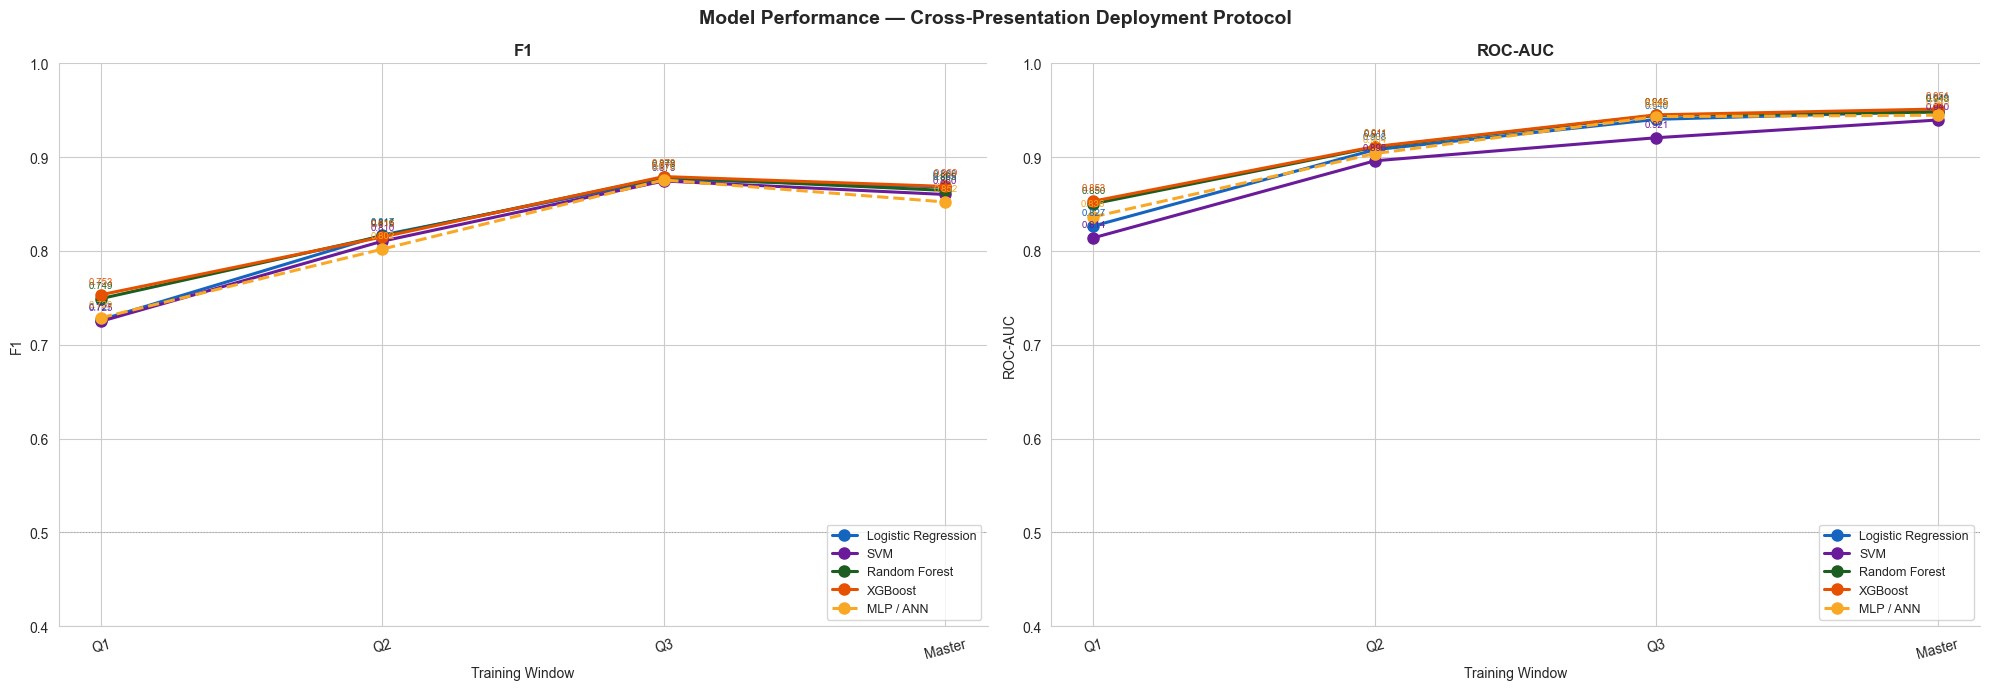

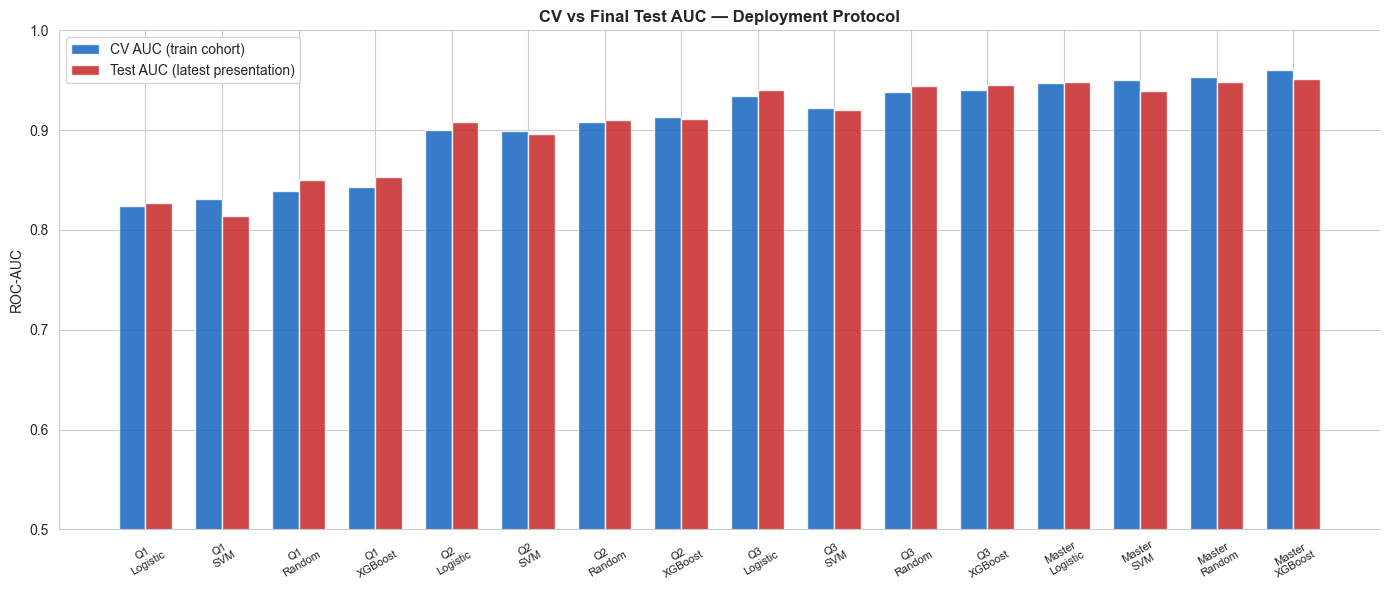

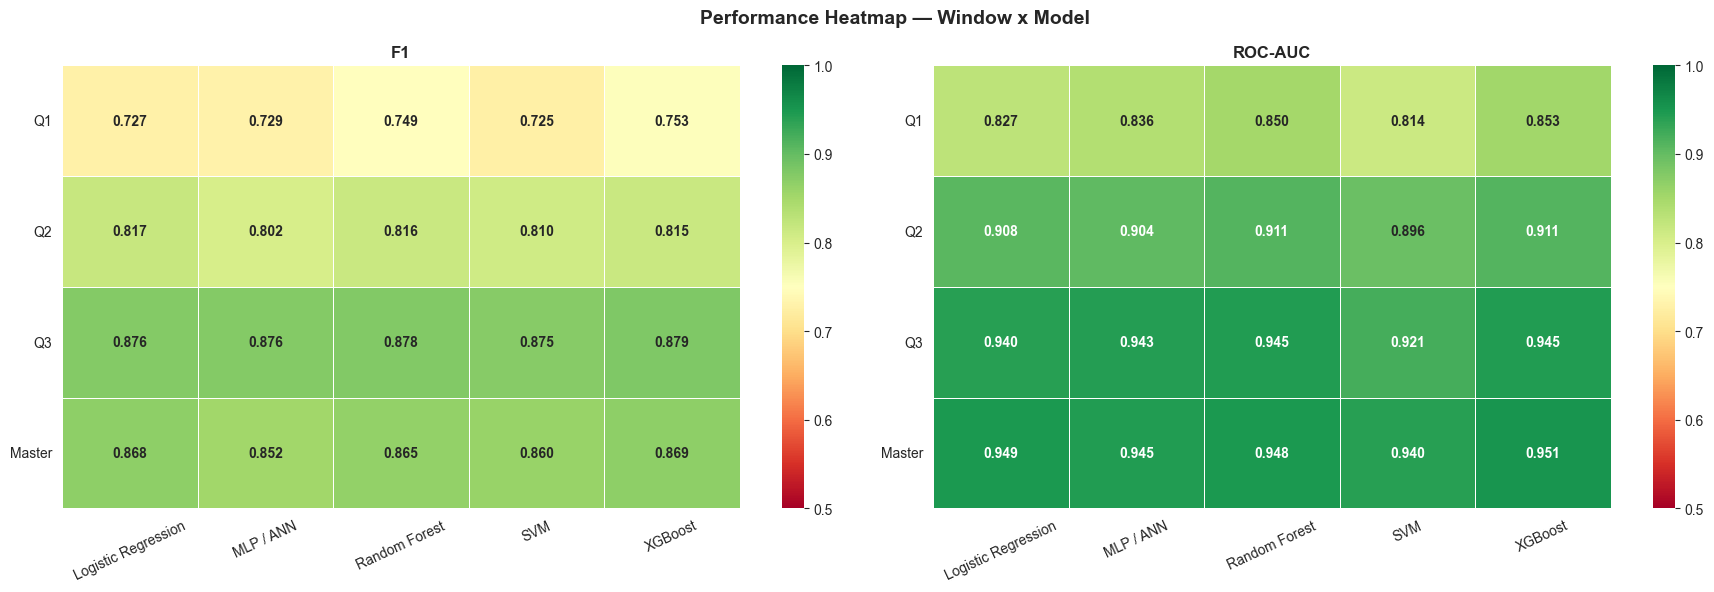

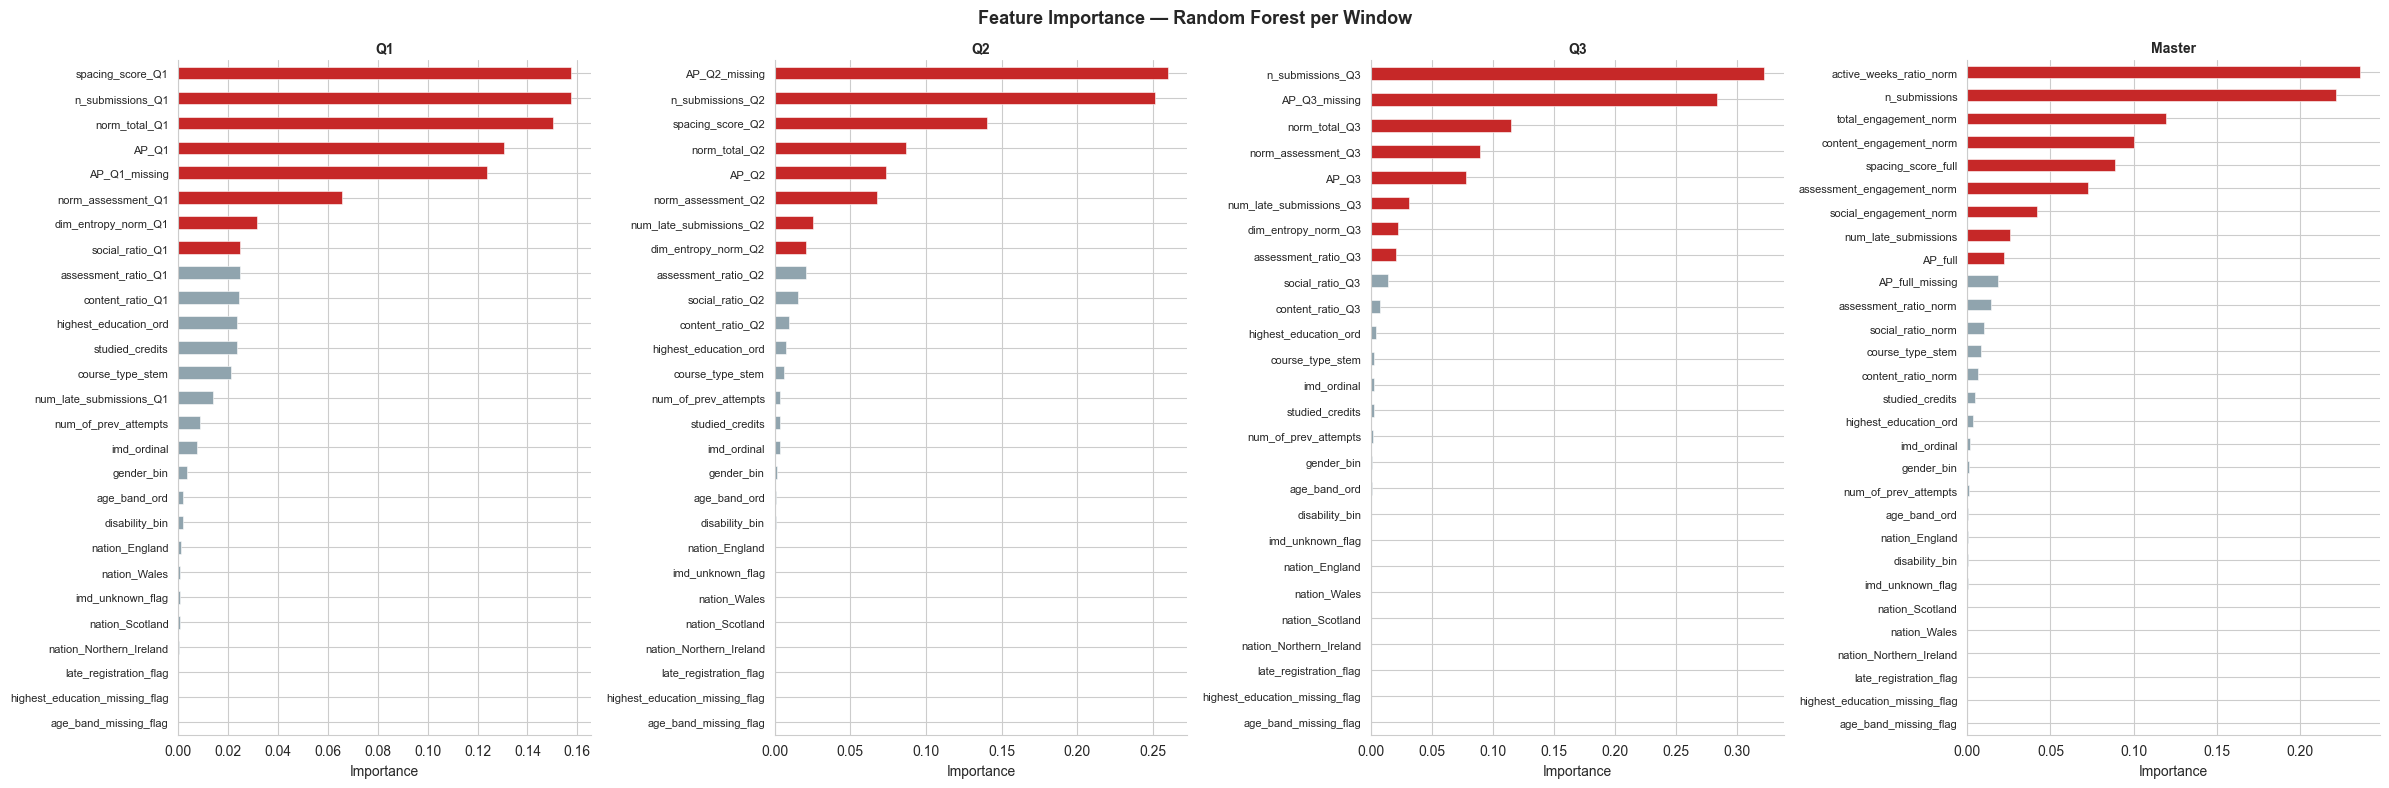

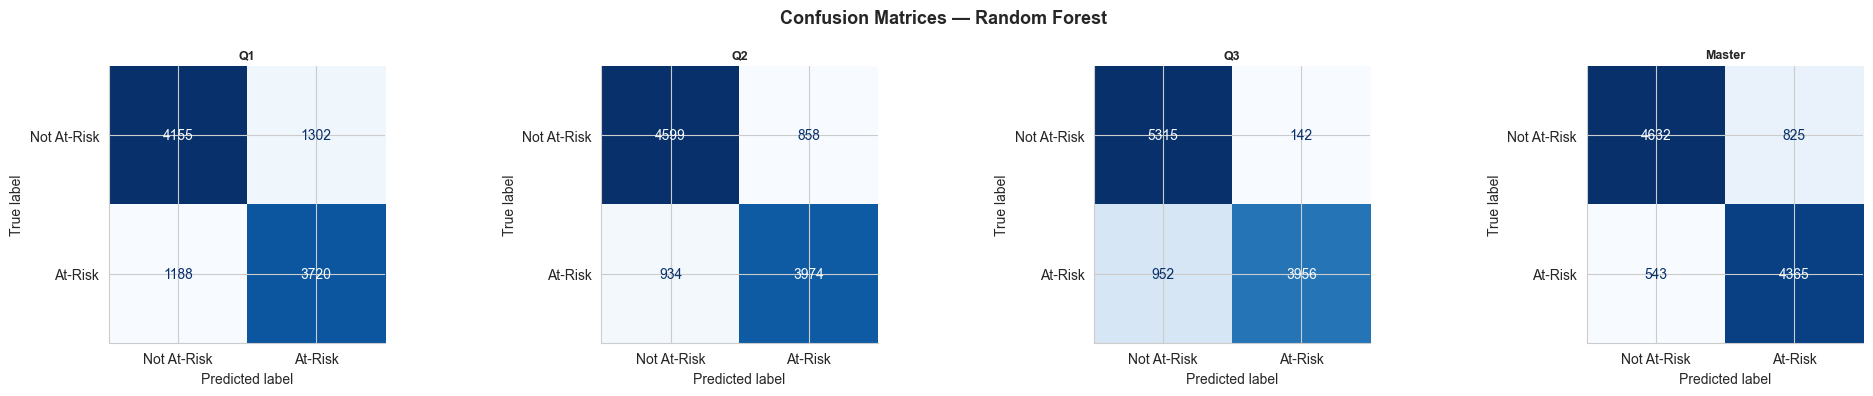

In [51]:
# =============================================================================
# CELL 11 — Visualisations
# =============================================================================

window_order = ["Q1", "Q2", "Q3", "Master"]
MODEL_COLORS = {
    "Logistic Regression": "#1565C0",
    "SVM":                 "#6A1B9A",
    "Random Forest":       "#1B5E20",
    "XGBoost":             "#E65100",
    "MLP / ANN":           "#F9A825",
    "LSTM":                "#C62828",
    "BiLSTM":              "#880E4F",
}

# ── Plot 1: Test performance across windows ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Model Performance — Cross-Presentation Deployment Protocol",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, ["F1", "ROC-AUC"]):
    for model_name, color in MODEL_COLORS.items():
        subset = results_test[
            results_test["Model"] == model_name].copy()
        if subset.empty:
            continue
        subset = (subset.set_index("Window")
                        .reindex(window_order)
                        .reset_index())
        ls = "--" if model_name in [
            "MLP / ANN", "LSTM", "BiLSTM"] else "-"
        ax.plot(subset["Window"], subset[metric],
                marker="o", linewidth=2.2, markersize=8,
                color=color, linestyle=ls, label=model_name)
        for _, row in subset.iterrows():
            if pd.notna(row[metric]):
                ax.annotate(
                    f"{row[metric]:.3f}",
                    (row["Window"], row[metric]),
                    textcoords="offset points",
                    xytext=(0, 8), ha="center",
                    fontsize=7, color=color)

    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xlabel("Training Window")
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=9, loc="lower right")
    ax.axhline(0.5, color="grey", linewidth=0.8,
               linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("window_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: CV AUC vs Test AUC ────────────────────────────────────────────────
trad_models  = ["Logistic Regression", "SVM",
                "Random Forest", "XGBoost"]
cv_sub   = results_cv[results_cv["Model"].isin(trad_models)].copy()
test_sub = results_test[results_test["Model"].isin(trad_models)].copy()
merged   = cv_sub[["Window","Model","CV AUC"]].merge(
    test_sub[["Window","Model","ROC-AUC"]],
    on=["Window","Model"]
)

fig, ax = plt.subplots(figsize=(14, 6))
x, width = np.arange(len(merged)), 0.35
ax.bar(x - width/2, merged["CV AUC"],   width,
       label="CV AUC (train cohort)",
       color="#1565C0", edgecolor="white", alpha=0.85)
ax.bar(x + width/2, merged["ROC-AUC"], width,
       label="Test AUC (latest presentation)",
       color="#C62828", edgecolor="white", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(
    merged["Window"] + "\n" + merged["Model"].str.split().str[0],
    rotation=30, fontsize=8)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC")
ax.set_title("CV vs Final Test AUC — Deployment Protocol",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("cv_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Heatmap ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Performance Heatmap — Window x Model",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, ["F1", "ROC-AUC"]):
    pivot = (results_test
             .pivot(index="Window", columns="Model", values=metric)
             .reindex(window_order))
    sns.heatmap(pivot, annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0.5, vmax=1.0,
                linewidths=0.5, ax=ax,
                annot_kws={"size": 10, "weight": "bold"})
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 4: Feature importance — RF per window ────────────────────────────────
rf_res = results_test[
    (results_test["Model"] == "Random Forest") &
    (results_test["_model"].notna())
].reset_index(drop=True)

if len(rf_res) > 0:
    n   = len(rf_res)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 8))
    if n == 1:
        axes = [axes]
    fig.suptitle("Feature Importance — Random Forest per Window",
                 fontsize=13, fontweight="bold")
    for ax, (_, row) in zip(axes, rf_res.iterrows()):
        clf   = row["_model"].named_steps["clf"]
        feats = row["_features"]
        imps  = pd.Series(
            clf.feature_importances_, index=feats).sort_values()
        colors = ["#C62828" if v >= imps.quantile(0.7)
                  else "#90A4AE" for v in imps.values]
        imps.plot(kind="barh", ax=ax, color=colors,
                  edgecolor="white", linewidth=0.4)
        ax.set_title(row["Window"], fontsize=10, fontweight="bold")
        ax.set_xlabel("Importance")
        ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Plot 5: Confusion matrices — RF ──────────────────────────────────────────
if len(rf_res) > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("Confusion Matrices — Random Forest",
                 fontsize=13, fontweight="bold")
    for ax, (_, row) in zip(axes, rf_res.iterrows()):
        ConfusionMatrixDisplay.from_predictions(
            row["_y_te"],
            row["_model"].predict(row["_X_te"]),
            display_labels=["Not At-Risk", "At-Risk"],
            cmap="Blues", ax=ax, colorbar=False
        )
        ax.set_title(row["Window"], fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=915c48ff-4287-4f39-af89-419738985e00' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>